In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="rocket")

In [12]:
DATA_FILE = "Airbnb_Open_Data.xlsx"
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


def save_plot(name):
    """Helper: save the current matplotlib figure into the images folder."""
    path = os.path.join(IMG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"  -> saved {path}")

In [13]:
# Load & clean
print("Loading dataset...")
df = pd.read_excel(DATA_FILE)
print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}")
print("\nCleaning data...")

Loading dataset...
Rows: 102599,  Columns: 26

Cleaning data...


In [14]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["neighbourhood_group"] = df["neighbourhood_group"].replace({
    "brookln": "Brooklyn",
    "manhatan": "Manhattan",
})

if "license" in df.columns:
    df = df.drop(columns=["license"])

before = len(df)
df = df.drop_duplicates()
print(f"  Removed {before - len(df)} duplicate rows")

important = ["price", "neighbourhood_group", "room_type"]
df = df.dropna(subset=important)

df = df[df["price"] > 0]
if "minimum_nights" in df.columns:
    df = df[(df["minimum_nights"] >= 1) & (df["minimum_nights"] <= 365)]
if "availability_365" in df.columns:
    df = df[(df["availability_365"] >= 0) & (df["availability_365"] <= 365)]

print(f"  Final shape after cleaning: {df.shape}")

  Removed 541 duplicate rows
  Final shape after cleaning: (97774, 25)


In [15]:
print("\nBasic statistics for price:")
print(df["price"].describe().round(2))


Basic statistics for price:
count    97774.00
mean       625.82
std        331.69
min         50.00
25%        340.00
50%        626.00
75%        913.00
max       1200.00
Name: price, dtype: float64


In [16]:
# 5. Visualisations
print("\nCreating charts...")


Creating charts...


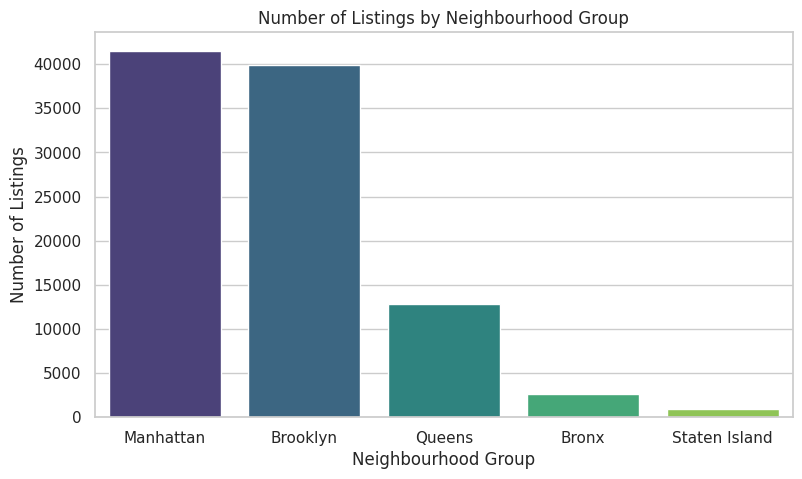

  -> saved images/listings_by_group.png


In [17]:
# Number of listings per neighbourhood group
order = df["neighbourhood_group"].value_counts().index
sns.countplot(data=df, x="neighbourhood_group", order=order, palette="viridis")
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.show()
save_plot("listings_by_group.png")


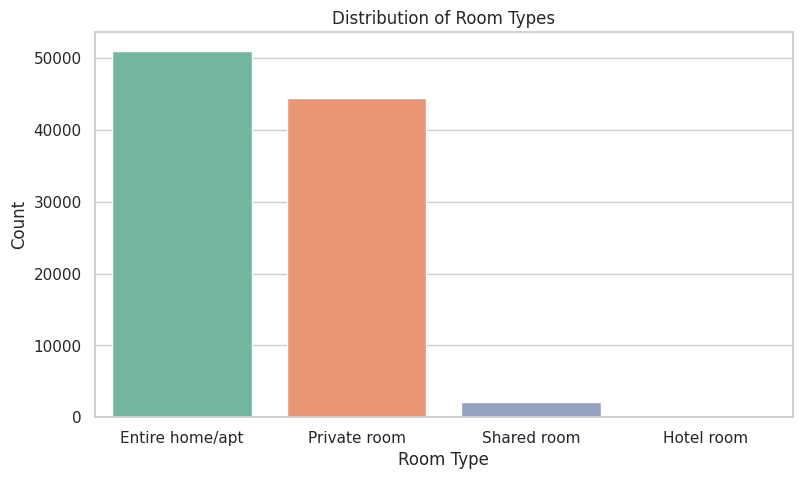

  -> saved images/room_type_distribution.png


In [18]:
# Room type distribution
sns.countplot(data=df, x="room_type",
              order=df["room_type"].value_counts().index,
              palette="Set2")
plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()
save_plot("room_type_distribution.png")

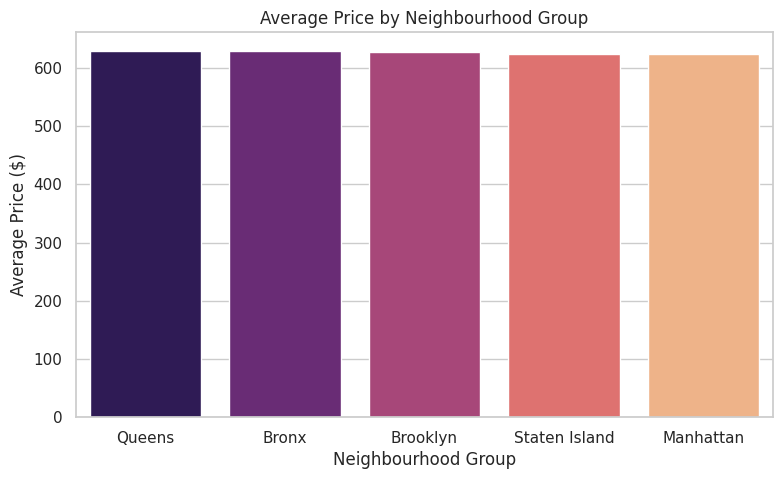

  -> saved images/avg_price_by_group.png


In [19]:
# Average price per neighbourhood group
avg_price = (df.groupby("neighbourhood_group")["price"]
               .mean().sort_values(ascending=False))
sns.barplot(x=avg_price.index, y=avg_price.values, palette="magma")
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")
plt.show()
save_plot("avg_price_by_group.png")

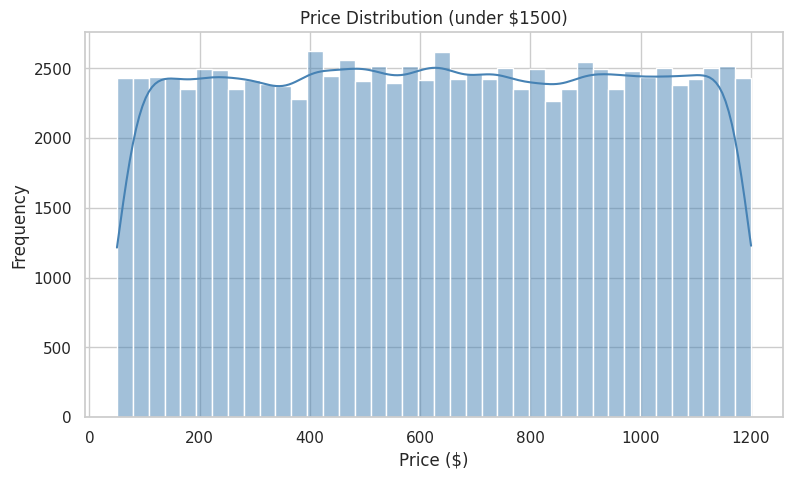

  -> saved images/price_distribution.png


In [20]:
# Price distribution (cut off extreme values for a clearer view)
sns.histplot(df[df["price"] < 1500]["price"], bins=40, kde=True, color="steelblue")
plt.title("Price Distribution (under $1500)")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()
save_plot("price_distribution.png")

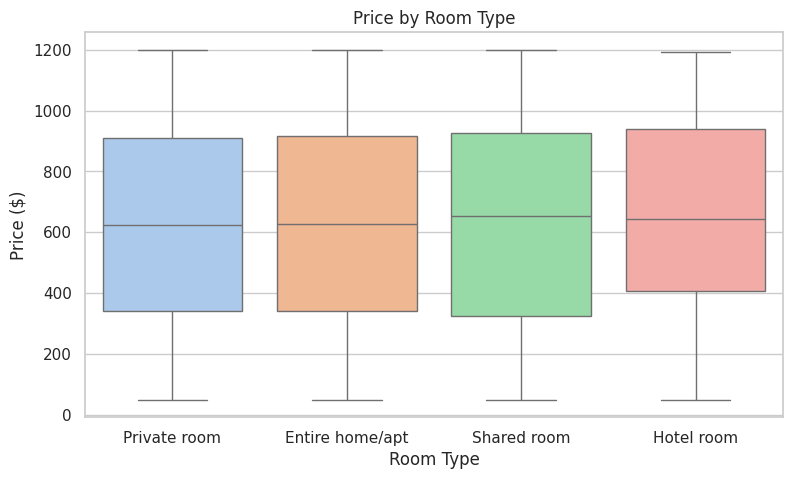

  -> saved images/price_by_room_type.png


In [21]:
# Price vs Room type (boxplot)
sns.boxplot(data=df[df["price"] < 1500],
            x="room_type", y="price", palette="pastel")
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()
save_plot("price_by_room_type.png")

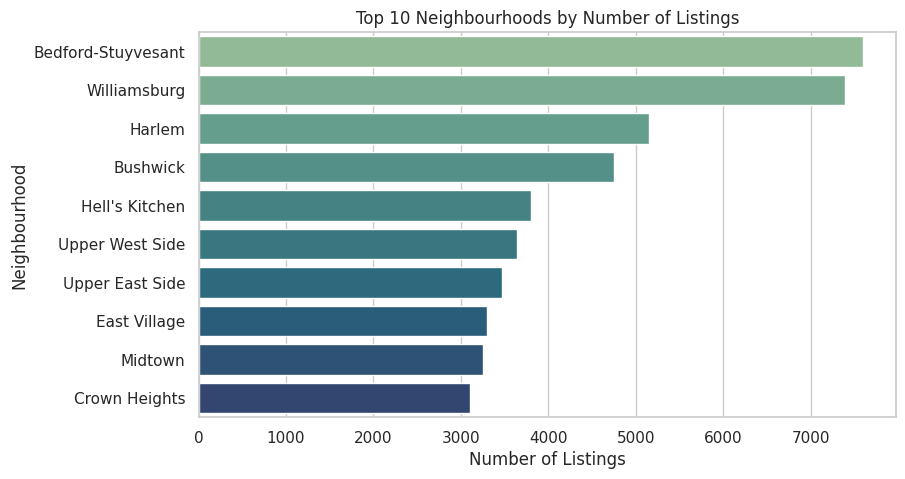

  -> saved images/top10_neighbourhoods.png


In [22]:
# Top 10 neighbourhoods by number of listings
top10 = df["neighbourhood"].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, palette="crest")
plt.title("Top 10 Neighbourhoods by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.show()
save_plot("top10_neighbourhoods.png")

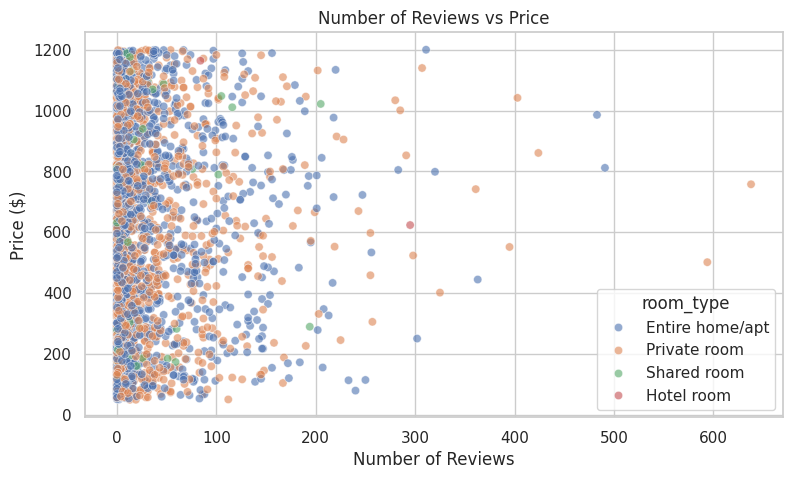

  -> saved images/reviews_vs_price.png


In [23]:
# Reviews vs Price (scatter)
sample = df[(df["price"] < 1500)].sample(min(3000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="number_of_reviews", y="price",
                hue="room_type", alpha=0.6)
plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.show()
save_plot("reviews_vs_price.png")

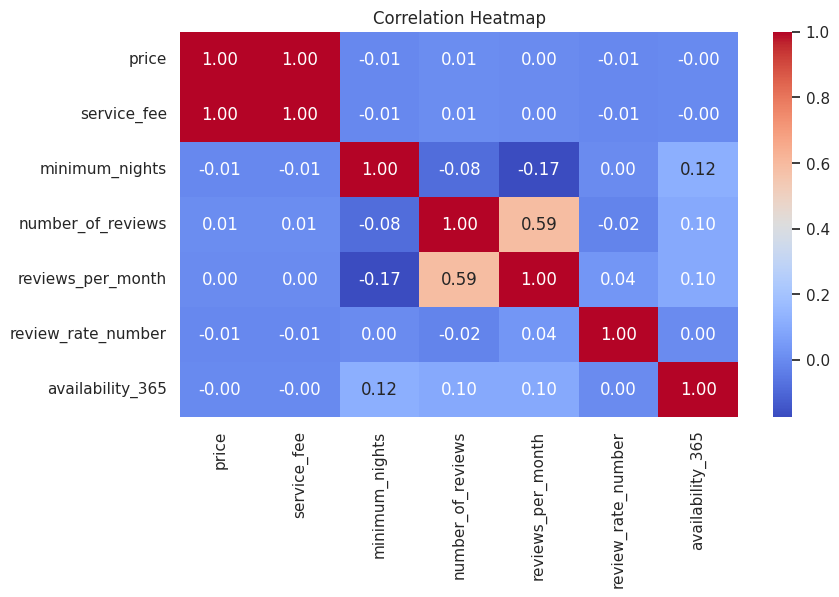

  -> saved images/heatmap.png


In [24]:
# Correlation heatmap of numeric columns
num_cols = ["price", "service_fee", "minimum_nights",
            "number_of_reviews", "reviews_per_month",
            "review_rate_number", "availability_365"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
save_plot("heatmap.png")

In [25]:
# Save the cleaned dataset
df.to_csv("airbnb_cleaned.csv", index=False)
print("\nCleaned dataset saved as 'airbnb_cleaned.csv'")
print("All done! Check the 'images/' folder for the charts.")


Cleaned dataset saved as 'airbnb_cleaned.csv'
All done! Check the 'images/' folder for the charts.
